# HyConEx pur + hypernet local — tous les jeux DLBAC

Ce notebook permet de :

1. **Entraîner** `HyConExLocalModel` sur les 11 jeux DLBAC entraînables (synthétiques + Amazon)
2. **Visualiser** les métriques (AUROC, accuracy, validité des contrefactuels)
3. **Comprendre** les trois types d'explication greffés :
   - **Hypernet local** (intrinsèque) : décomposition `W(z)·z + b(z)`
   - **Pont entrée** : gradient `∂logit/∂oh_*`
   - **Contrefactuels** HyConEx : `x' = clamp(x + δ, 0, 1)`

**Prérequis** : exécuter depuis `HyConEx_from_scratch/` ou `notebooks/`, environnement `hyconex`, cache one-hot (`prepare_dlbac_datasets.py`).

> Les jeux Amazon (~14k colonnes one-hot) prennent ~15–20 min chacun sur GPU ; les synthétiques ~1 min.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

_cwd = Path.cwd().resolve()
ROOT = None
for p in (_cwd, _cwd.parent):
    if (p / "prepare_dlbac_datasets.py").is_file():
        ROOT = p
        break
if ROOT is None:
    raise FileNotFoundError("Ouvrez le notebook depuis HyConEx_from_scratch/ ou notebooks/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from prepare_dlbac_datasets import discover_dlbac_datasets
from train_hyconex_pure_local_dlbac import (
    RESULTS_DIR,
    discover_specs,
    train_one,
)
from train_nouveau_module_dlbac_quantile import build_onehot_splits
from hyconex_pure_local import (
    HyConExLocalTrainer,
    explain_counterfactual,
    explain_input_bridge,
    explain_local_hypernet,
)
from hyconex_from_scratch.config import TrainConfig

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ALL_SPECS = {s.name: s for s in discover_specs()}
print(f"Jeux entraînables ({len(ALL_SPECS)}):", sorted(ALL_SPECS.keys()))
print(f"Device PyTorch: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"Résultats: {RESULTS_DIR}")

Jeux entraînables (11): ['amazon1', 'amazon2', 'amazon3', 'u4k-r4k-auth11k', 'u4k-r4k-auth21k', 'u4k-r4k-auth22k', 'u4k-r6k-auth28k', 'u4k-r7k-auth20k', 'u5k-r5k-auth12k', 'u5k-r5k-auth19k', 'u6k-r6k-auth32k']
Device PyTorch: cuda
Résultats: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch\results\hyconex_pure_local_dlbac


## Configuration

| Variable | Description |
|----------|-------------|
| `DATASETS` | `None` = tous les jeux ; ou liste ex. `["u4k-r4k-auth11k", "amazon1"]` |
| `RETRAIN` | `True` = ré-entraîne même si JSON existe |
| `SKIP_AMAZON` | `True` = seulement les jeux synthétiques (plus rapide) |
| `VERBOSE` | Afficher les epochs pendant l'entraînement |

In [2]:
DATASETS = None          # None = tous
RETRAIN = False          # True pour forcer ré-entraînement
SKIP_AMAZON = False      # True pour ignorer amazon1/2/3
VERBOSE = True

names = sorted(ALL_SPECS.keys()) if DATASETS is None else list(DATASETS)
if SKIP_AMAZON:
    names = [n for n in names if not n.startswith("amazon")]
print("Jeux sélectionnés:", names)

Jeux sélectionnés: ['amazon1', 'amazon2', 'amazon3', 'u4k-r4k-auth11k', 'u4k-r4k-auth21k', 'u4k-r4k-auth22k', 'u4k-r6k-auth28k', 'u4k-r7k-auth20k', 'u5k-r5k-auth12k', 'u5k-r5k-auth19k', 'u6k-r6k-auth32k']


## Entraînement

Chaque jeu produit `{dataset}_results.json` et `{dataset}_model.pt` dans `results/hyconex_pure_local_dlbac/`.

In [3]:
rows: list[dict] = []

for name in names:
    out_path = RESULTS_DIR / f"{name}_results.json"
    if out_path.exists() and not RETRAIN:
        print(f"[cache] {name} — chargement {out_path.name}")
        row = json.loads(out_path.read_text(encoding="utf-8"))
    else:
        print(f"[train] {name} ...")
        row = train_one(ALL_SPECS[name], save_dir=RESULTS_DIR, verbose=VERBOSE)
        out_path.write_text(json.dumps(row, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    rows.append(row)
    flag = "PASS" if row["acceptable"] else "FAIL"
    print(f"  [{flag}] auroc={row['test_auroc']:.4f} acc={row['test_accuracy']:.4f} cf={row['cf_validity']:.4f}")

(RESULTS_DIR / "summary.json").write_text(
    json.dumps(rows, indent=2, ensure_ascii=False, default=str), encoding="utf-8"
)
print(f"\nTerminé — {len(rows)} jeux, summary.json mis à jour.")

[cache] amazon1 — chargement amazon1_results.json
  [PASS] auroc=0.8478 acc=0.9429 cf=1.0000
[train] amazon2 ...

=== amazon2 (HyConEx PUR + hypernet local) ===
  features: 9476 | classes: 2
  Device: cuda
[Epoch 001/25] loss=0.2095 val_acc=0.9436 best_val_acc=0.9436
[Epoch 002/25] loss=0.1217 val_acc=0.9466 best_val_acc=0.9466
[Epoch 003/25] loss=0.0681 val_acc=0.9466 best_val_acc=0.9466
[Epoch 004/25] loss=0.0319 val_acc=0.9380 best_val_acc=0.9466
[Epoch 005/25] loss=0.0776 val_acc=0.9395 best_val_acc=0.9466
[Epoch 006/25] loss=0.0124 val_acc=0.9346 best_val_acc=0.9466
[Epoch 007/25] loss=0.0064 val_acc=0.9413 best_val_acc=0.9466
[Epoch 008/25] loss=0.0038 val_acc=0.9422 best_val_acc=0.9466
[Epoch 009/25] loss=0.0024 val_acc=0.9384 best_val_acc=0.9466
[Epoch 010/25] loss=0.0017 val_acc=0.9428 best_val_acc=0.9466
[Epoch 011/25] loss=0.0021 val_acc=0.9392 best_val_acc=0.9466
[Epoch 012/25] loss=0.0006 val_acc=0.9357 best_val_acc=0.9466
[Epoch 013/25] loss=0.0018 val_acc=0.9407 best_val

## Tableau récapitulatif

In [4]:
def row_to_flat(r: dict) -> dict:
    kind = "amazon" if r["dataset"].startswith("amazon") else "synthetic"
    return {
        "dataset": r["dataset"],
        "kind": kind,
        "n_features": r["num_features"],
        "n_classes": r["num_classes"],
        "latent_dim": r.get("latent_dim"),
        "val_acc": r["best_val_accuracy"],
        "test_acc": r["test_accuracy"],
        "test_auroc": r["test_auroc"],
        "cf_validity": r["cf_validity"],
        "cf_l1": r["cf_proximity_l1"],
        "threshold": r["accept_threshold"],
        "pass": r["acceptable"],
    }

df = pd.DataFrame([row_to_flat(r) for r in rows]).sort_values("test_auroc", ascending=False)
display(df.style.background_gradient(subset=["test_auroc", "test_acc"], cmap="YlGn").format({
    "val_acc": "{:.3f}", "test_acc": "{:.3f}", "test_auroc": "{:.4f}",
    "cf_validity": "{:.3f}", "cf_l1": "{:.1f}",
}))

,dataset,kind,n_features,n_classes,latent_dim,val_acc,test_acc,test_auroc,cf_validity,cf_l1,threshold,pass
8,u5k-r5k-auth12k,synthetic,170,16,32,0.992,0.993,0.9999,1.000,21.5,0.880000,True
3,u4k-r4k-auth11k,synthetic,157,16,32,0.977,0.972,0.9997,1.000,31.4,0.880000,True
10,u6k-r6k-auth32k,synthetic,154,16,32,0.911,0.903,0.9977,1.000,30.6,0.880000,True
9,u5k-r5k-auth19k,synthetic,164,16,32,0.904,0.898,0.9957,0.999,28.0,0.880000,True
4,u4k-r4k-auth21k,synthetic,146,16,32,0.875,0.869,0.9947,1.000,33.5,0.880000,True
7,u4k-r7k-auth20k,synthetic,152,16,32,0.900,0.878,0.9947,1.000,30.6,0.880000,True
6,u4k-r6k-auth28k,synthetic,145,16,32,0.819,0.816,0.9909,1.000,33.7,0.880000,True
5,u4k-r4k-auth22k,synthetic,133,16,32,0.732,0.721,0.9770,0.997,36.6,0.880000,True
0,amazon1,amazon,14419,2,64,0.944,0.943,0.8478,1.000,5.5,0.720000,True
2,amazon3,amazon,9124,2,64,0.946,0.944,0.8287,1.000,3.9,0.720000,True


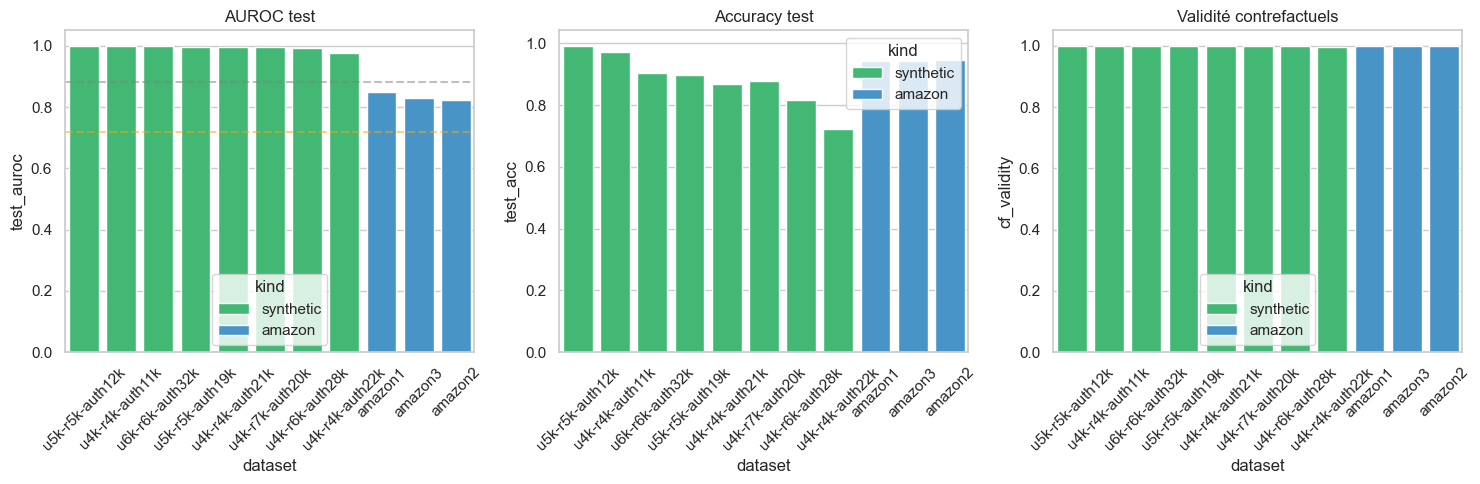

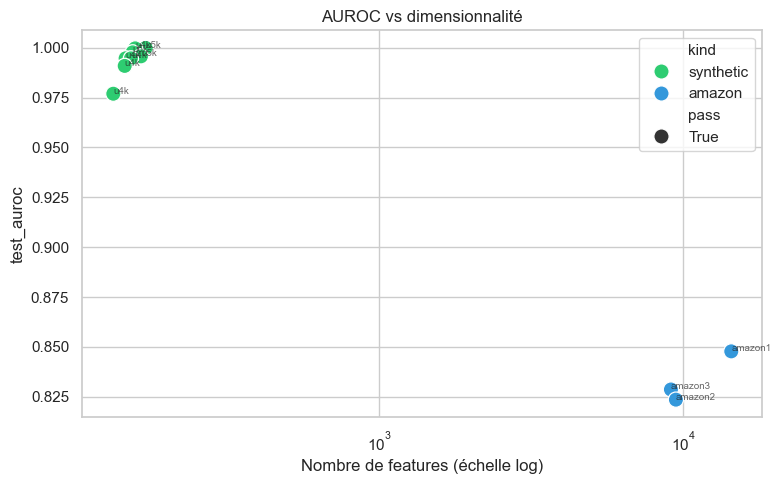

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = {"synthetic": "#2ecc71", "amazon": "#3498db"}

sns.barplot(data=df, x="dataset", y="test_auroc", hue="kind", dodge=False, palette=palette, ax=axes[0])
axes[0].axhline(0.88, color="gray", ls="--", alpha=0.5, label="seuil synth.")
axes[0].axhline(0.72, color="orange", ls="--", alpha=0.5, label="seuil amazon")
axes[0].set_title("AUROC test")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=df, x="dataset", y="test_acc", hue="kind", dodge=False, palette=palette, ax=axes[1])
axes[1].set_title("Accuracy test")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=df, x="dataset", y="cf_validity", hue="kind", dodge=False, palette=palette, ax=axes[2])
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Validité contrefactuels")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="n_features", y="test_auroc", hue="kind", style="pass", s=120, palette=palette, ax=ax2)
ax2.set_xscale("log")
ax2.set_xlabel("Nombre de features (échelle log)")
ax2.set_title("AUROC vs dimensionnalité")
for _, r in df.iterrows():
    ax2.annotate(r["dataset"].split("-")[0], (r["n_features"], r["test_auroc"]), fontsize=7, alpha=0.7)
plt.tight_layout()
plt.show()

## Comprendre les métriques

| Métrique | Signification | Bonne valeur |
|----------|---------------|-------------|
| **AUROC** | Capacité à séparer les classes (indépendant du seuil) | Synth. ≥ 0,88 ; Amazon ≥ 0,72 |
| **Accuracy** | % de bonnes prédictions | Élevée, mais peut tromper si classes déséquilibrées |
| **CF validity** | % de contrefactuels qui atteignent la classe cible | Proche de 1,0 |
| **CF proximity L1** | Distance L1 moyenne `‖x' - x‖₁` | Plus bas = CF plus proche (souvent plus sparse sur Amazon) |

**Architecture** : encodeur `x→z` → hyperréseau fabrique `W(z), b(z)` → `logit = W·z + b`. Les explications locales lisent exactement ces termes (pas post-hoc).

**Synthétique vs Amazon** : les jeux synthétiques ont ~150 features one-hot ; Amazon ~14k colonnes sparse → entraînement plus lent, seuil AUROC plus bas.

## Explorer un jeu en détail

Modifiez `FOCUS_DATASET` et `SAMPLE_IDX` ci-dessous.

In [6]:
FOCUS_DATASET = "amazon1"   # ou "u4k-r4k-auth11k", etc.
SAMPLE_IDX = 0

focus_row = next(r for r in rows if r["dataset"] == FOCUS_DATASET)
spec = ALL_SPECS[FOCUS_DATASET]
splits = build_onehot_splits(spec, val_size=0.2, random_state=42, use_cache=True)

ckpt_path = RESULTS_DIR / f"{FOCUS_DATASET}_model.pt"
payload = torch.load(ckpt_path, map_location="cpu", weights_only=False)
cfg = TrainConfig(**payload["config"])
trainer = HyConExLocalTrainer(cfg)
trainer._ensure_model(payload["input_dim"], payload["num_classes"])
trainer.model.load_state_dict(payload["state_dict"])
trainer.model.to(trainer.device)
trainer.model.eval()

y_true = int(splits.y_test[SAMPLE_IDX])
print(f"Jeu: {FOCUS_DATASET} | features: {splits.x_train.shape[1]} | classes: {splits.num_classes}")
print(f"Échantillon {SAMPLE_IDX} | vrai: {splits.class_names[y_true]}")
print(f"Métriques test — AUROC: {focus_row['test_auroc']:.4f} | acc: {focus_row['test_accuracy']:.4f}")

Jeu: amazon1 | features: 14419 | classes: 2
Échantillon 0 | vrai: grant
Métriques test — AUROC: 0.8478 | acc: 0.9429


### 1. Explication hypernet local (intrinsèque)

Pour chaque requête, HyConEx fabrique un classifieur linéaire sur `z` : on affiche les termes `w_ci × z_i` qui composent le logit de la classe prédite, et la classe rivale.

logit(grant) = +0.100 + +0.098 + +0.090 + +0.086 + +0.076 + ... + b=+0.455 = +1.910

Prédit: grant | Rival: deny | Marge logit: 3.966


,dim,z,w,contribution,abs_contrib
0,z_46,0.365117,0.273816,0.099975,0.099975
1,z_5,0.374446,0.260571,0.097570,0.097570
2,z_27,-0.310692,-0.288637,0.089677,0.089677
3,z_35,-0.361424,-0.237067,0.085682,0.085682
4,z_48,0.305192,0.249546,0.076159,0.076159
5,z_41,-0.293073,-0.258344,0.075714,0.075714
6,z_1,0.273256,0.272416,0.074439,0.074439
7,z_19,-0.246349,-0.277681,0.068406,0.068406
8,z_59,-0.240001,-0.250641,0.060154,0.060154
9,z_11,-0.319006,-0.182970,0.058369,0.058369


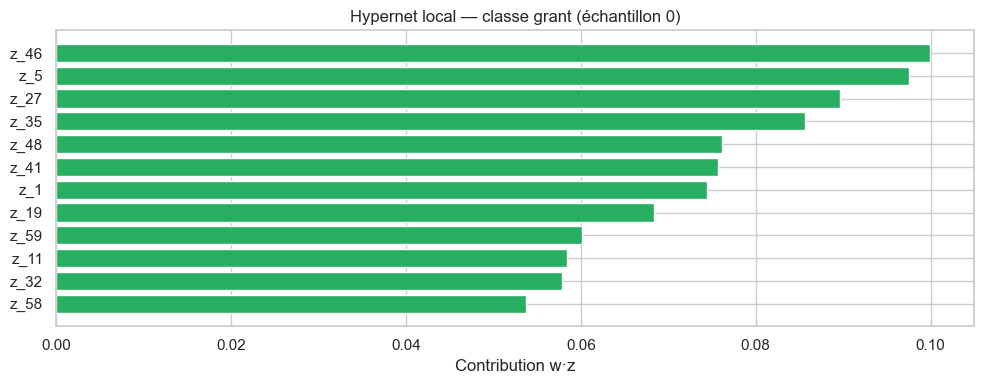

In [7]:
loc = explain_local_hypernet(
    trainer, splits.x_test, SAMPLE_IDX,
    class_names=splits.class_names, y_true=y_true,
)
print(loc["summary_text"])
print(f"\nPrédit: {loc['y_pred_name']} | Rival: {loc['rival_class_name']} | Marge logit: {loc['margin_logit']:.3f}")

terms = pd.DataFrame(loc["top_terms_explained"])
terms["abs_contrib"] = terms["contribution"].abs()
display(terms)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#27ae60" if c > 0 else "#e74c3c" for c in terms["contribution"]]
ax.barh(terms["dim"][::-1], terms["contribution"][::-1], color=colors[::-1])
ax.set_xlabel("Contribution w·z")
ax.set_title(f"Hypernet local — classe {loc['explained_class_name']} (échantillon {SAMPLE_IDX})")
plt.tight_layout()
plt.show()

### 2. Pont vers les entrées `oh_*`

Gradient `∂logit_c/∂x_j` : quelles colonnes one-hot influencent la décision via l'encodeur. Plus post-hoc que l'hypernet local, mais lisible sur les features d'entrée.

In [8]:
bridge = explain_input_bridge(
    trainer, splits.x_test, SAMPLE_IDX,
    feature_names=splits.feature_names, class_names=splits.class_names,
)
bridge_df = pd.DataFrame(bridge["top_features"])
display(bridge_df)

active = np.where(splits.x_test[SAMPLE_IDX] > 0)[0]
print(f"Features actives (non nulles) sur cet échantillon: {len(active)}")

,feature,importance,value
0,oh_7859,0.749596,0.0
1,oh_4499,0.634751,0.0
2,oh_4583,0.615106,0.0
3,oh_4594,0.596376,0.0
4,oh_7127,0.589644,0.0
5,oh_5133,0.588528,0.0
6,oh_12151,0.586182,0.0
7,oh_1091,0.586180,0.0
8,oh_4757,0.580844,0.0
9,oh_4580,0.574004,0.0


Features actives (non nulles) sur cet échantillon: 8


### 3. Contrefactuel HyConEx

Modification minimale apprise `x' = clamp(x + δ, 0, 1)` pour atteindre une classe cible.

In [9]:
with torch.no_grad():
    x_t = torch.tensor(splits.x_test[SAMPLE_IDX:SAMPLE_IDX+1], dtype=torch.float32, device=trainer.device)
    pred = int(trainer.model(x_t).argmax().item())
target = 1 - pred if splits.num_classes == 2 else (pred + 1) % splits.num_classes

cf = explain_counterfactual(
    trainer, splits.x_test, SAMPLE_IDX, target,
    feature_names=splits.feature_names, class_names=splits.class_names, y_true=y_true,
)
print(f"Cible CF: {cf['y_target_name']} | Valide: {cf['valid']} | {cf['n_changes']} features modifiées")
display(pd.DataFrame(cf["changes"]))

Cible CF: deny | Valide: True | 19 features modifiées


,feature,from,to,delta
0,oh_12142,0.0,0.679283,0.679283
1,oh_9039,0.0,0.590729,0.590729
2,oh_12894,0.0,0.546684,0.546684
3,oh_7696,0.0,0.513420,0.513420
4,oh_13435,0.0,0.422654,0.422654
5,oh_8233,0.0,0.338801,0.338801
6,oh_5583,0.0,0.248413,0.248413
7,oh_13541,0.0,0.217740,0.217740
8,oh_2345,0.0,0.210798,0.210798
9,oh_13295,0.0,0.191694,0.191694


## Synthèse PASS / FAIL

In [10]:
n_pass = int(df["pass"].sum())
n_fail = len(df) - n_pass
print(f"PASS: {n_pass}/{len(df)} | FAIL: {n_fail}/{len(df)}")
if n_fail:
    print("Échecs:", df.loc[~df["pass"], "dataset"].tolist())

by_kind = df.groupby("kind")[["test_auroc", "test_acc", "cf_validity"]].mean()
print("\nMoyennes par type de jeu:")
display(by_kind)

PASS: 11/11 | FAIL: 0/11

Moyennes par type de jeu:


,test_auroc,test_acc,cf_validity
kind,,,
amazon,0.833346,0.944707,1.000000
synthetic,0.993777,0.881135,0.999498
